# Taller de Inteligencia Artificial
Predicción de la concentración de Monóxido de Carbono (CO) mediante Regresión En este taller se analiza un conjunto de datos de calidad del aire de la estación **PARR** (condado de Pulaski, Little Rock, Arkansas, EE.UU.), con mediciones diarias durante el año **2023**.La variable que se desea predecir es la **concentración máxima diaria de monóxido de carbono en 8 horas (ppm)**, a partir de variables derivadas de la fecha (mes, día de la semana, estacionalidad anual) y de la cantidad de observaciones registradas cada día.Primero se realiza una limpieza y exploración de los datos para conocer su distribución y las relaciones entre las variables, utilizando histogramas, series de tiempo y mapas de calor.A partir de los resultados obtenidos, se prepara la información para construir modelos de aprendizaje automático. Se implementa una **Regresión Lineal** y, posteriormente, un **Árbol de Decisión** y un **Random Forest**, buscando estimar la concentración de CO a partir de las variables disponibles.Finalmente, se comparan los valores reales con las predicciones obtenidas y se analizan los residuos para observar el comportamiento de los modelos.

## Importamos los paquetes

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style("whitegrid")

## Cargamos el conjunto de datos

In [4]:
df_original = pd.read_csv("ad_viz_plotval_data.csv")
df_original.head()

,Date,Source,Site ID,POC,Daily Max 8-hour CO Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2023,AQS,51190007,2,0.9,ppm,10,PARR,19,79.0,...,Carbon monoxide,54,30780,"Little Rock-North Little Rock-Conway, AR",5,Arkansas,119,Pulaski,34.756189,-92.281296
1,01/02/2023,AQS,51190007,2,0.7,ppm,8,PARR,24,100.0,...,Carbon monoxide,54,30780,"Little Rock-North Little Rock-Conway, AR",5,Arkansas,119,Pulaski,34.756189,-92.281296
2,01/04/2023,AQS,51190007,2,0.8,ppm,9,PARR,8,33.0,...,Carbon monoxide,54,30780,"Little Rock-North Little Rock-Conway, AR",5,Arkansas,119,Pulaski,34.756189,-92.281296
3,01/05/2023,AQS,51190007,2,0.8,ppm,9,PARR,24,100.0,...,Carbon monoxide,54,30780,"Little Rock-North Little Rock-Conway, AR",5,Arkansas,119,Pulaski,34.756189,-92.281296
4,01/06/2023,AQS,51190007,2,0.7,ppm,8,PARR,24,100.0,...,Carbon monoxide,54,30780,"Little Rock-North Little Rock-Conway, AR",5,Arkansas,119,Pulaski,34.756189,-92.281296


## Consultamos la información básica del conjunto de datos

In [5]:
df_original.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Date                               364 non-null    object 
 1   Source                             364 non-null    object 
 2   Site ID                            364 non-null    int64  
 3   POC                                364 non-null    int64  
 4   Daily Max 8-hour CO Concentration  364 non-null    float64
 5   Units                              364 non-null    object 
 6   Daily AQI Value                    364 non-null    int64  
 7   Local Site Name                    364 non-null    object 
 8   Daily Obs Count                    364 non-null    int64  
 9   Percent Complete                   364 non-null    float64
 10  AQS Parameter Code                 364 non-null    int64  
 11  AQS Parameter Description          364 non-null    object 

Revisamos cuántos valores distintos tiene cada columnaEste paso es importante: si una columna tiene **un solo valor distinto**, no aporta información al modelo(por ejemplo, todos los registros pertenecen a la misma estación de monitoreo).

In [6]:
df_original.nunique()

,0
Date,364
Source,1
Site ID,1
POC,1
Daily Max 8-hour CO Concentration,14
Units,1
Daily AQI Value,14
Local Site Name,1
Daily Obs Count,11
Percent Complete,11


**Limpieza y preparación de datos**

Se eliminan las columnas constantes (estación, estado, coordenadas, unidades) y se renombran las variables de interés a nombres más cortos. Además, se derivan las siguientes características a partir de la fecha:

* **Mes**: Mes del año (1 a 12).
* **Dia_Anio**: Día del año (1 a 365).
* **Dia_Semana**: Día de la semana (0 = lunes, 6 = domingo).
* **Fin_Semana**: Variable binaria (1 para fin de semana, 0 en caso contrario).
* **Sen_Anual / Cos_Anual**: Transformación cíclica que captura la estacionalidad anual, dando continuidad entre diciembre y enero para el modelo lineal.

In [45]:
df = df_original.copy()

# Convertimos la fecha a tipo datetime
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")

# Renombramos las columnas de interés
df = df.rename(columns={
    "Daily Max 8-hour CO Concentration": "CO_ppm",
    "Daily AQI Value": "AQI",
    "Daily Obs Count": "Num_Observaciones",
    "Percent Complete": "Porcentaje_Completo"
})

# Creamos las variables derivadas de la fecha
df["Mes"] = df["Date"].dt.month
df["Dia_Anio"] = df["Date"].dt.dayofyear
df["Dia_Semana"] = df["Date"].dt.dayofweek
df["Fin_Semana"] = (df["Dia_Semana"] >= 5).astype(int)
df["Sen_Anual"] = np.sin(2 * np.pi * df["Dia_Anio"] / 365)
df["Cos_Anual"] = np.cos(2 * np.pi * df["Dia_Anio"] / 365)

df[["Date", "CO_ppm", "AQI", "Mes", "Dia_Anio", "Dia_Semana", "Num_Observaciones"]].head()

,Date,CO_ppm,AQI,Mes,Dia_Anio,Dia_Semana,Num_Observaciones
0,2023-01-01,0.9,10,1,1,6,19
1,2023-01-02,0.7,8,1,2,0,24
2,2023-01-04,0.8,9,1,4,2,8
3,2023-01-05,0.8,9,1,5,3,24
4,2023-01-06,0.7,8,1,6,4,24


## Verificamos valores faltantes

In [46]:
df.isnull().sum().sum()

np.int64(0)

**Selección de variables del modelo**

Se ubica la variable objetivo (`CO_ppm`) al final del DataFrame para facilitar la separación entre las variables de entrada y la variable a predecir.

> **Nota:** Se excluye la columna `AQI` debido a que el Índice de Calidad del Aire se calcula directamente a partir de la concentración de CO. Incluirla generaría una fuga de información (*data leakage*), resultando en un modelo trivial con resultados irreales.

In [47]:
columnas_modelo = ["Mes", "Dia_Semana", "Fin_Semana", "Sen_Anual", "Cos_Anual",
                   "Num_Observaciones", "CO_ppm"]

datos = df[columnas_modelo].copy()
datos.head()

,Mes,Dia_Semana,Fin_Semana,Sen_Anual,Cos_Anual,Num_Observaciones,CO_ppm
0,1,6,1,0.017213,0.999852,19,0.9
1,1,0,0,0.034422,0.999407,24,0.7
2,1,2,0,0.068802,0.997630,8,0.8
3,1,3,0,0.085965,0.996298,24,0.8
4,1,4,0,0.103102,0.994671,24,0.7


## Obtenemos un resumen estadístico de las variables

In [10]:
datos.describe().round(3)

,Mes,Dia_Semana,Fin_Semana,Sen_Anual,Cos_Anual,Num_Observaciones,CO_ppm
count,364.000,364.000,364.000,364.000,364.000,364.000,364.000
mean,6.541,3.014,0.288,-0.000,-0.003,23.588,0.485
std,3.445,2.006,0.454,0.709,0.707,2.076,0.281
min,1.000,0.000,0.000,-1.000,-1.000,8.000,0.000
25%,4.000,1.000,0.000,-0.707,-0.709,24.000,0.300
50%,7.000,3.000,0.000,-0.004,-0.004,24.000,0.500
75%,10.000,5.000,1.000,0.707,0.703,24.000,0.700
max,12.000,6.000,1.000,1.000,1.000,24.000,1.300


## Identificamos las características del conjunto de datos

In [11]:
datos.columns

Index(['Mes', 'Dia_Semana', 'Fin_Semana', 'Sen_Anual', 'Cos_Anual',
       'Num_Observaciones', 'CO_ppm'],
      dtype='object')

## Visualización Básica

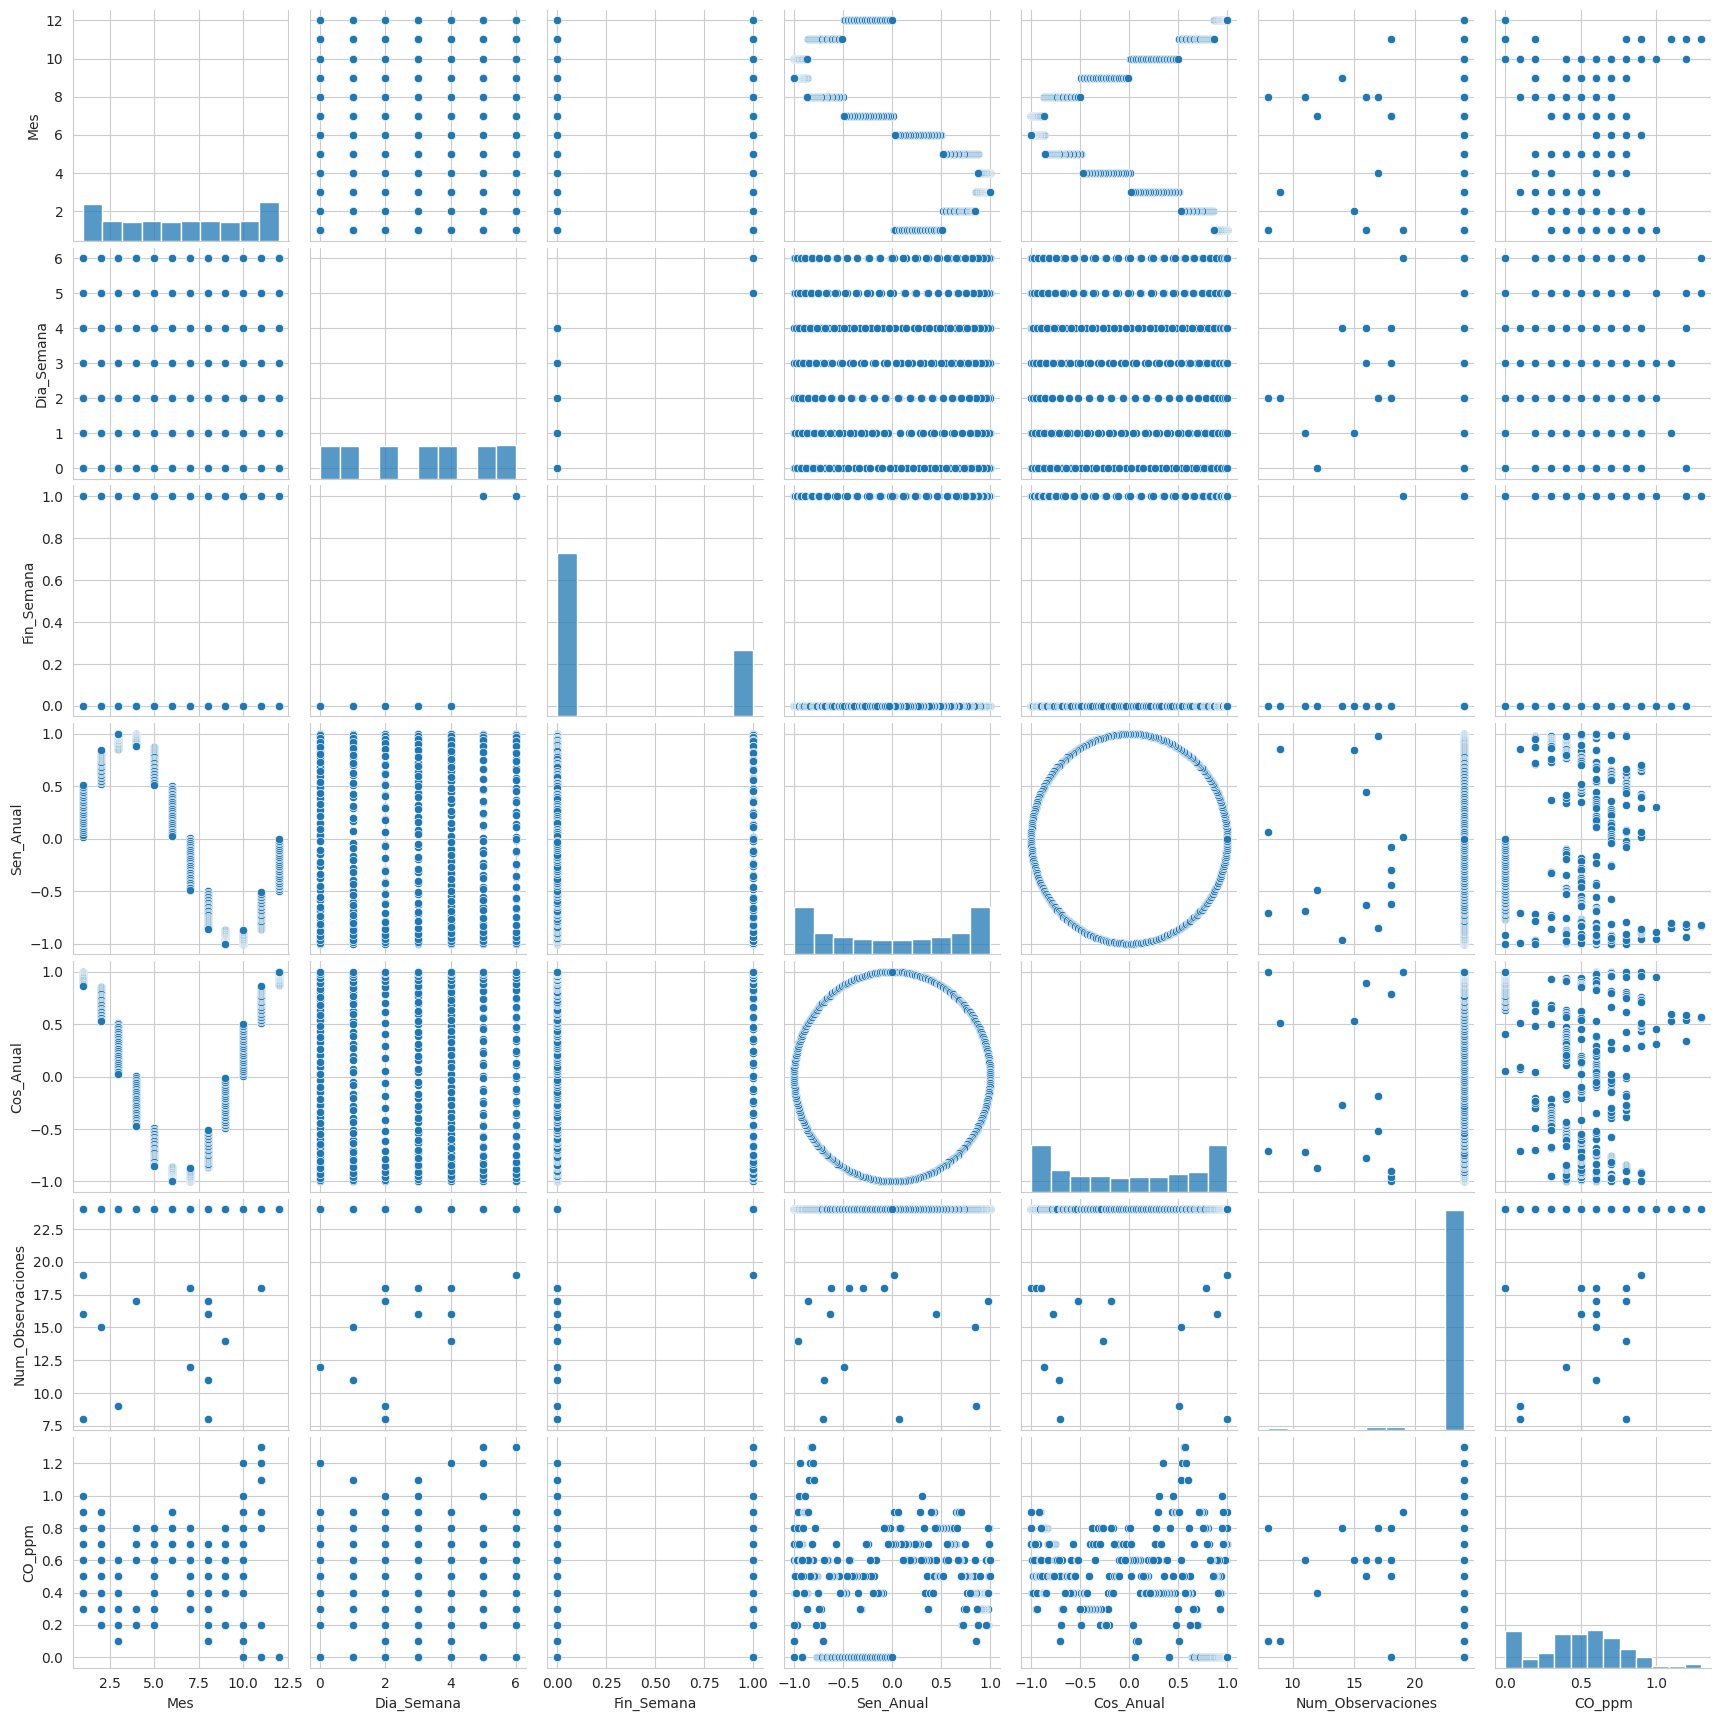

In [12]:
# Visualizamos la relación entre todas las variables del conjunto de datos
sns.pairplot(datos)

## Distribución de la concentración de CO

Text(0.5, 1.0, 'Histograma de la concentración diaria de CO')

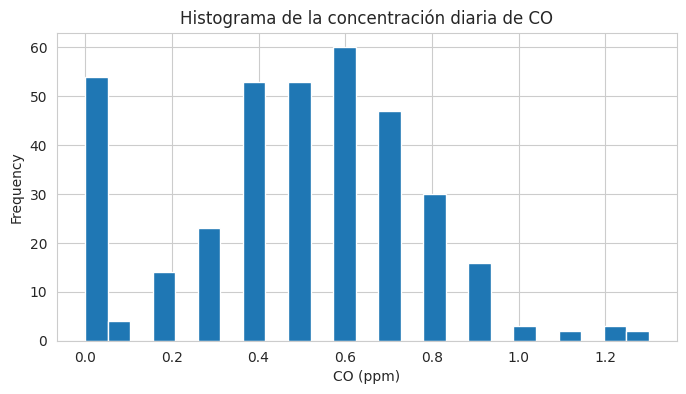

In [13]:
datos["CO_ppm"].plot.hist(bins=25, figsize=(8, 4))
plt.xlabel("CO (ppm)")
plt.title("Histograma de la concentración diaria de CO")

'\nDensidad: ¿Dónde están concentrados los datos?\n'

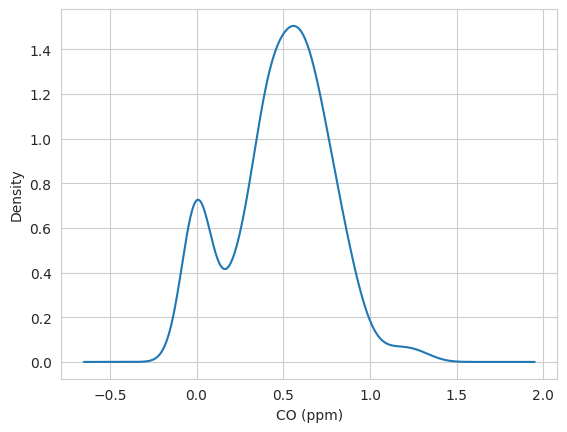

In [14]:
# Estimamos la distribución de la concentración de CO
datos["CO_ppm"].plot.density()
plt.xlabel("CO (ppm)")

"""
Densidad: ¿Dónde están concentrados los datos?
"""

**Evolución anual de la concentración de CO**

Al tratarse de una serie de tiempo, permite analizar la variación de la variable a lo largo del año. Se evidencia un patron estacional claro: concentraciones más elevadas durante los meses fríos y valores reducidos en los meses cálidos.

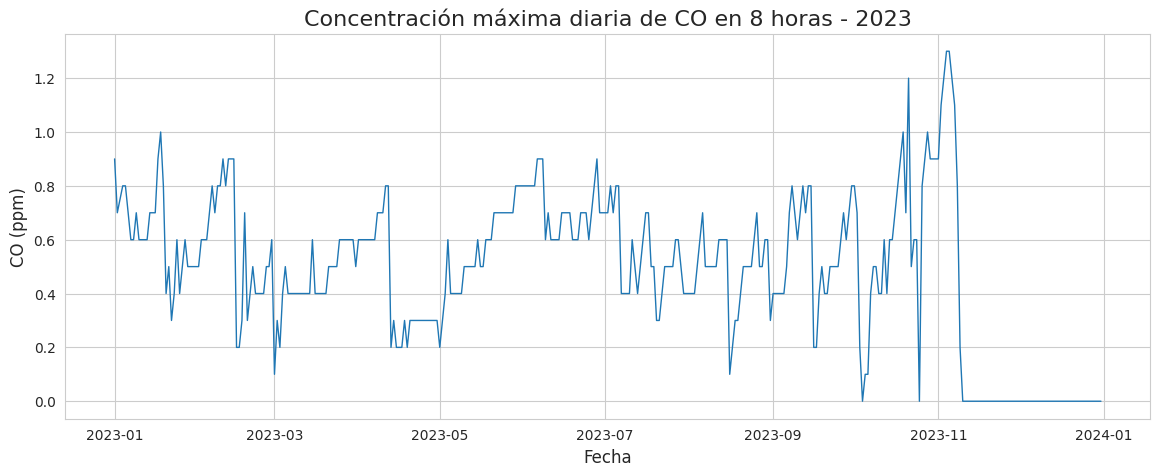

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["CO_ppm"], linewidth=1)
plt.title("Concentración máxima diaria de CO en 8 horas - 2023", fontsize=16)
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("CO (ppm)", fontsize=12)
plt.show()

## Promedio mensual de CO

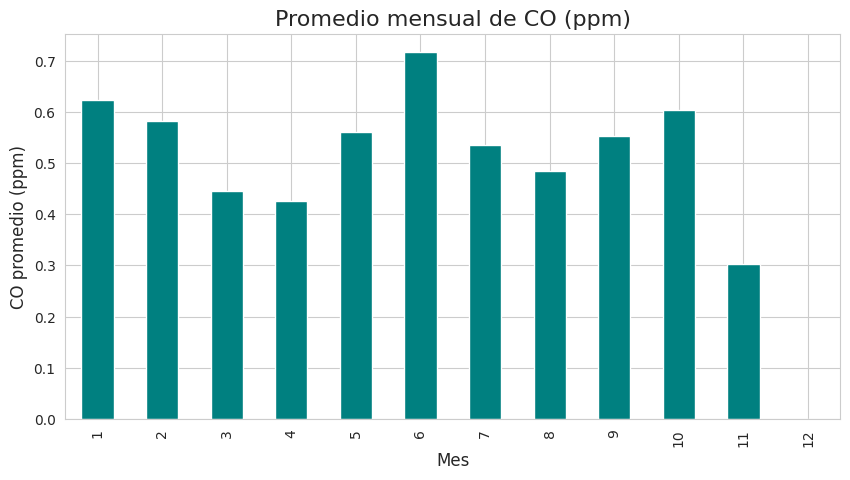

,CO_ppm
Mes,
1,0.623
2,0.582
3,0.445
4,0.427
5,0.561
6,0.717
7,0.535
8,0.484
9,0.553


In [16]:
promedio_mensual = df.groupby("Mes")["CO_ppm"].mean()

plt.figure(figsize=(10, 5))
promedio_mensual.plot(kind="bar", color="teal")
plt.title("Promedio mensual de CO (ppm)", fontsize=16)
plt.xlabel("Mes", fontsize=12)
plt.ylabel("CO promedio (ppm)", fontsize=12)
plt.show()

promedio_mensual.round(3)

# Matriz de correlación y heatmap

<strong> Análisis de correlación entre las variables <strong>

In [17]:
# Seleccionamos las variables numéricas del conjunto de datos
numeric_df = datos.select_dtypes(include=[np.number])

# Calculamos la matriz de correlación
numeric_df.corr().round(4)

,Mes,Dia_Semana,Fin_Semana,Sen_Anual,Cos_Anual,Num_Observaciones,CO_ppm
Mes,1.0000,0.0085,0.0056,-0.7829,0.0094,0.0552,-0.3466
Dia_Semana,0.0085,1.0000,0.7917,0.0002,0.0097,0.0768,-0.0245
Fin_Semana,0.0056,0.7917,1.0000,0.0001,0.0086,0.1119,0.0083
Sen_Anual,-0.7829,0.0002,0.0001,1.0000,-0.0003,0.0434,0.0569
Cos_Anual,0.0094,0.0097,0.0086,-0.0003,1.0000,0.0309,-0.3021
Num_Observaciones,0.0552,0.0768,0.1119,0.0434,0.0309,1.0000,-0.0173
CO_ppm,-0.3466,-0.0245,0.0083,0.0569,-0.3021,-0.0173,1.0000


<strong> Mapa de calor <strong>

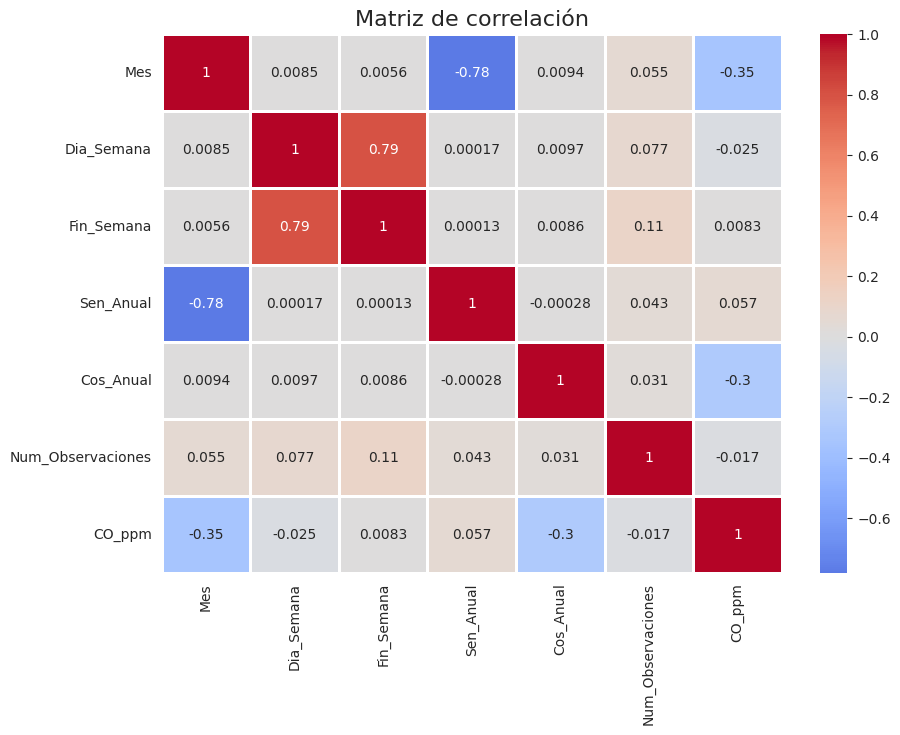

In [18]:
# Representamos visualmente la matriz de correlación
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, linewidths=2, cmap="coolwarm", center=0)
plt.title("Matriz de correlación", fontsize=16)
plt.show()

<strong> Definición de variables para el modelo <strong>

In [19]:
# Obtenemos los nombres de las variables
l_column = list(datos.columns)
# Contamos la cantidad de variables
len_feature = len(l_column)
l_column

['Mes',
 'Dia_Semana',
 'Fin_Semana',
 'Sen_Anual',
 'Cos_Anual',
 'Num_Observaciones',
 'CO_ppm']

In [20]:
# Definimos las variables de entrada y la variable objetivo
x = datos[l_column[0:len_feature-1]]
y = datos[l_column[len_feature-1]]
x.head()

,Mes,Dia_Semana,Fin_Semana,Sen_Anual,Cos_Anual,Num_Observaciones
0,1,6,1,0.017213,0.999852,19
1,1,0,0,0.034422,0.999407,24
2,1,2,0,0.068802,0.997630,8
3,1,3,0,0.085965,0.996298,24
4,1,4,0,0.103102,0.994671,24


In [21]:
y.head()

,CO_ppm
0,0.9
1,0.7
2,0.8
3,0.8
4,0.7


# Dividimos entrenamiento-prueba

<strong> División de los datos <strong>

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=123
    )

print("Datos de entrenamiento:", x_train.shape)
print("Datos de prueba:", x_test.shape)

Datos de entrenamiento: (254, 6)
Datos de prueba: (110, 6)


# Ajuste y entrenamiento del modelo

<strong> Ajuste del modelo de Regresión Lineal <strong>

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

lm = LinearRegression()

In [25]:
lm.fit(x_train, y_train)

LinearRegression()

In [26]:
print("El término de intersección del modelo lineal:", lm.intercept_)

El término de intersección del modelo lineal: 0.7764878301850275


<strong> Obtención de los coeficientes del modelo <strong>

In [27]:
print("Los coeficientes del modelo lineal:", lm.coef_)

Los coeficientes del modelo lineal: [-0.06837847 -0.00765948  0.02657908 -0.25757476 -0.10089304  0.00760533]


In [28]:
cdf = pd.DataFrame(data=lm.coef_, index=x_train.columns, columns=["Coeficientes"])
cdf

,Coeficientes
Mes,-0.068378
Dia_Semana,-0.007659
Fin_Semana,0.026579
Sen_Anual,-0.257575
Cos_Anual,-0.100893
Num_Observaciones,0.007605


<strong> Error estándar y estadístico t de los coeficientes <strong>El estadístico **t** indica qué tan significativa es cada variable: entre más grande sea su valorabsoluto, más confianza tenemos en que esa variable realmente influye sobre la concentración de CO.

In [29]:
# Obtenemos el número de observaciones y variables
n = x_train.shape[0]
k = x_train.shape[1]
dfN = n - k

# Generamos las predicciones del conjunto de entrenamiento
train_pred = lm.predict(x_train)

# Calculamos el error cuadrático total
train_error = np.square(train_pred - y_train)
sum_error = np.sum(train_error)

# Calculamos el error estándar de cada coeficiente
se = [0] * k
for i in range(k):
    col = list(x_train.columns)[i]
    r = (sum_error / dfN)
    r = r / np.sum(np.square(x_train[col] - x_train[col].mean()))
    se[i] = np.sqrt(r)

cdf["Error Estandar"] = se
cdf["Estadistico-t"] = cdf["Coeficientes"] / cdf["Error Estandar"]
cdf.round(4)

,Coeficientes,Error Estandar,Estadistico-t
Mes,-0.0684,0.0042,-16.1692
Dia_Semana,-0.0077,0.0072,-1.0623
Fin_Semana,0.0266,0.0324,0.8199
Sen_Anual,-0.2576,0.0201,-12.8449
Cos_Anual,-0.1009,0.0209,-4.8170
Num_Observaciones,0.0076,0.0064,1.1977


<strong> Relación entre las variables y la concentración de CO <strong>

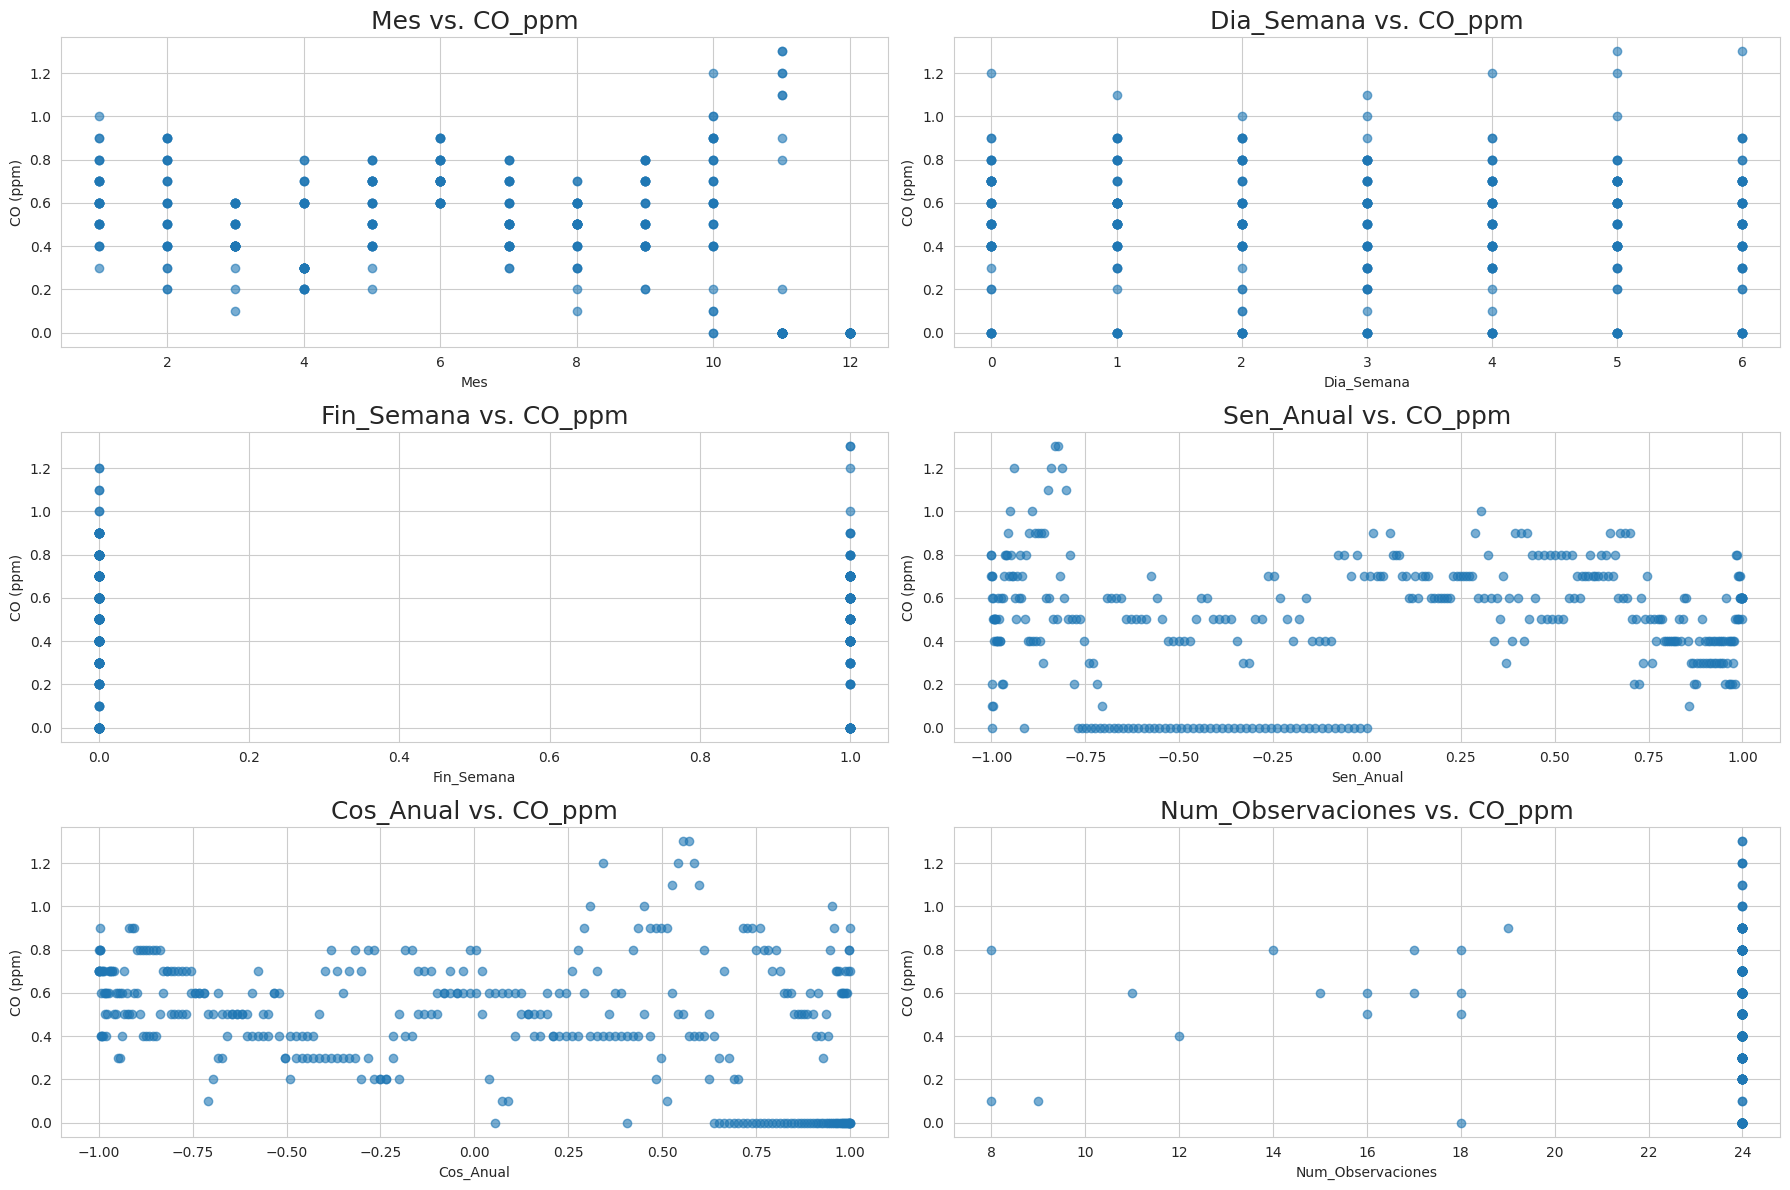

In [30]:
l = list(cdf.index)

from matplotlib import gridspec

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 2)

for i in range(len(l)):
    ax = plt.subplot(gs[i])
    ax.scatter(datos[l[i]], datos["CO_ppm"], alpha=0.6)
    ax.set_title(l[i] + " vs. CO_ppm", fontdict={'fontsize': 18})
    ax.set_xlabel(l[i])
    ax.set_ylabel("CO (ppm)")

plt.tight_layout()
plt.show()

## Matrices de evaluación de estimación de error

<strong> Generación y evaluación de las predicciones <strong>

In [31]:
predictions = lm.predict(x_test)
print("Tipo del objeto predicho :", type(predictions))
print("Tamaño del objeto predicho:", predictions.shape)

Tipo del objeto predicho : <class 'numpy.ndarray'>
Tamaño del objeto predicho: (110,)


In [32]:
print("MAE  (Error absoluto medio):  ", round(metrics.mean_absolute_error(y_test, predictions), 4))
print("MSE  (Error cuadrático medio):", round(metrics.mean_squared_error(y_test, predictions), 4))
print("RMSE (Raíz del MSE):          ", round(float(np.sqrt(metrics.mean_squared_error(y_test, predictions))), 4))
print("R2   (Coeficiente de determinación):", round(metrics.r2_score(y_test, predictions), 4))

MAE  (Error absoluto medio):   0.1853
MSE  (Error cuadrático medio): 0.0561
RMSE (Raíz del MSE):           0.2369
R2   (Coeficiente de determinación): 0.2956


El **R²** indica qué porcentaje de la variación del CO logra explicar el modelo. Un valor cercano a 1significa un ajuste muy bueno, y cercano a 0 que el modelo casi no explica el comportamiento de los datos.

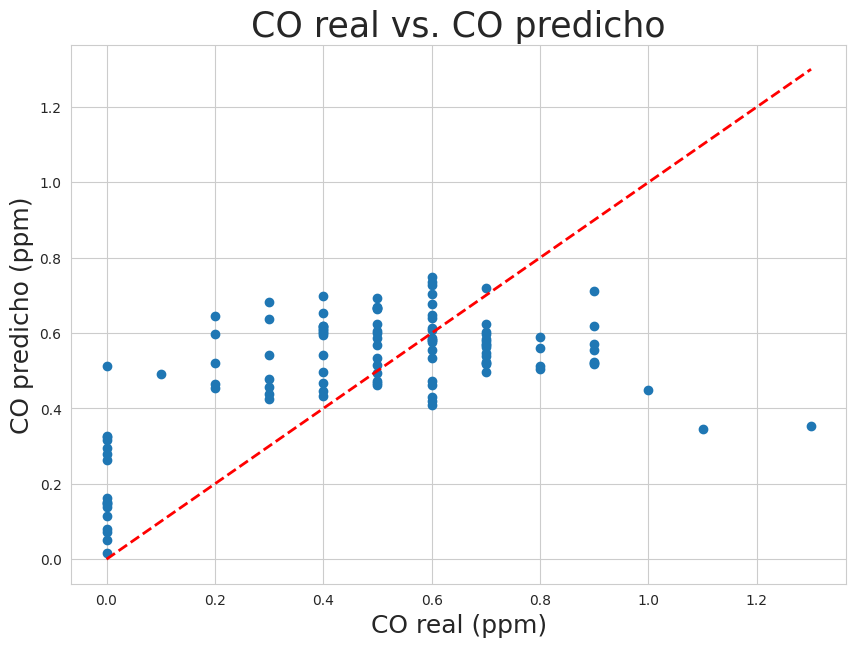

In [33]:
""" DIAGRAMA DE DISPERSIÓN """

plt.figure(figsize=(10, 7))
plt.title("CO real vs. CO predicho", fontsize=25)
plt.xlabel("CO real (ppm)", fontsize=18)
plt.ylabel("CO predicho (ppm)", fontsize=18)
plt.scatter(x=y_test, y=predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.show()

<strong> Análisis de los residuos del modelo <strong>

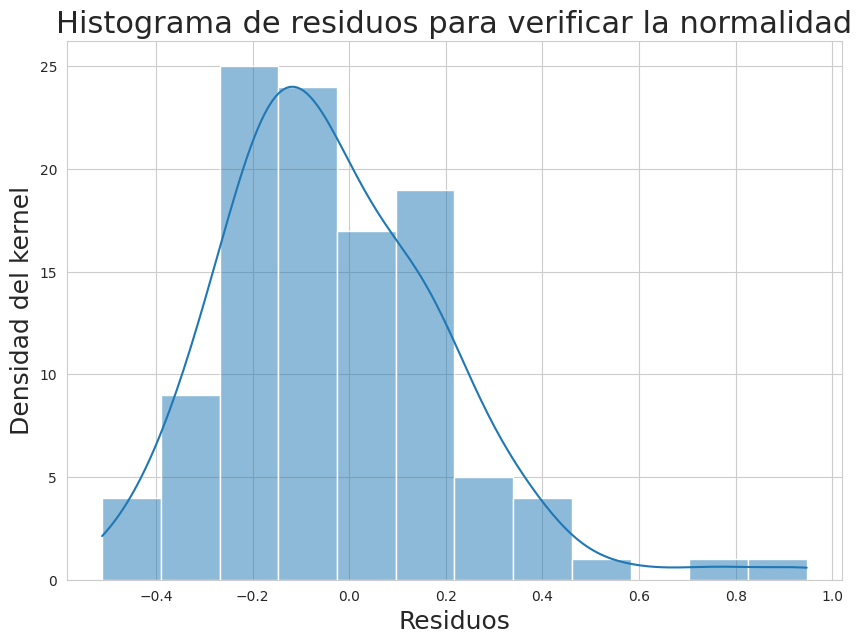

In [34]:
plt.figure(figsize=(10, 7))
plt.title("Histograma de residuos para verificar la normalidad", fontsize=22)
plt.xlabel("Residuos", fontsize=18)
plt.ylabel("Densidad del kernel", fontsize=18)
sns.histplot(y_test - predictions, kde=True)
plt.show()

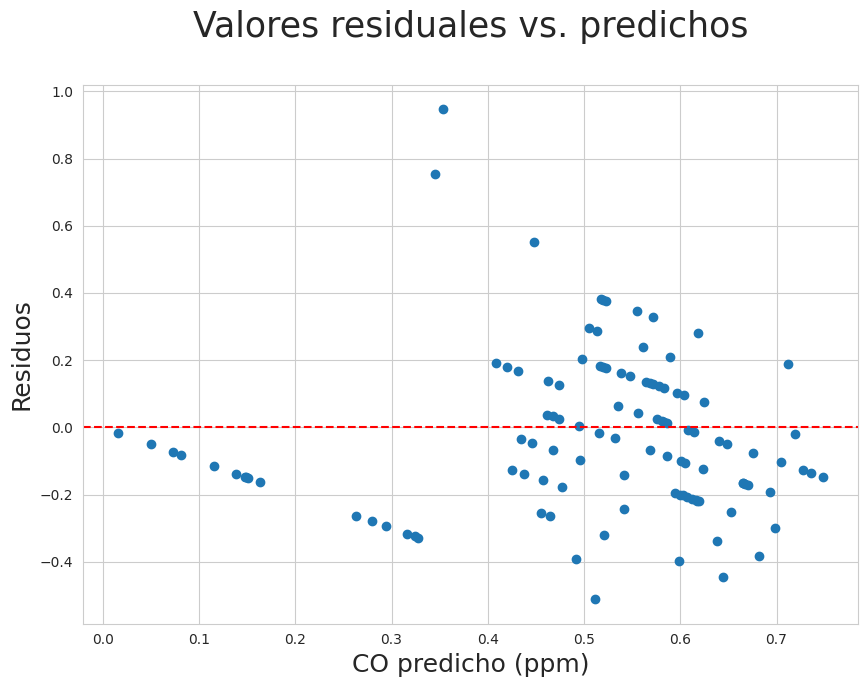

In [35]:
# Diagrama de dispersión de residuos

plt.figure(figsize=(10, 7))
plt.title("Valores residuales vs. predichos\n", fontsize=25)
plt.xlabel("CO predicho (ppm)", fontsize=18)
plt.ylabel("Residuos", fontsize=18)
plt.scatter(x=predictions, y=y_test - predictions)
plt.axhline(y=0, color='r', linestyle='--')
plt.show()

Árbol de Decisión y Random ForestLa relación entre la fecha y la concentración de CO no es estrictamente lineal, por lo que ahoraprobamos modelos basados en árboles, que sí pueden capturar relaciones no lineales.

In [36]:
from sklearn import tree
from sklearn.ensemble import RandomForestRegressor

<strong> Árbol de Decisión <strong>

In [37]:
# Creación del modelo (max_depth controla los niveles de decisión)
tree_model = tree.DecisionTreeRegressor(max_depth=5, random_state=10)
tree_model.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=5, random_state=10)

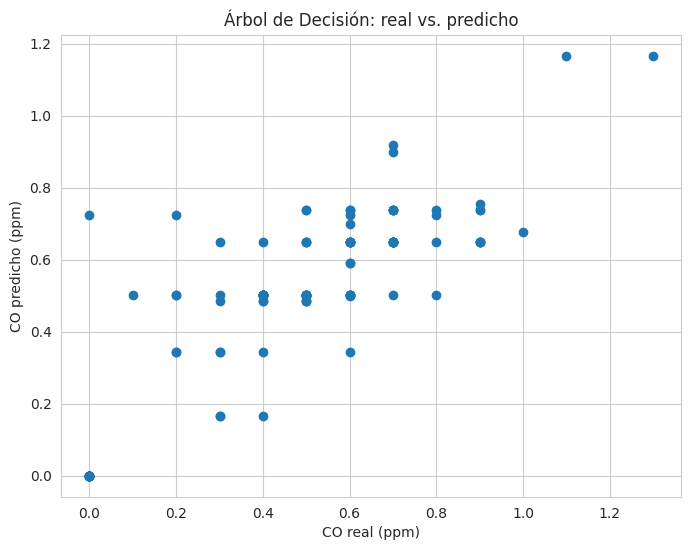

Mean square error (MSE): 0.0252
R2: 0.6836


In [38]:
# Hacemos predicciones con el árbol
test_pred_tree = tree_model.predict(x_test)

plt.figure(figsize=(8, 6))
plt.scatter(x=y_test, y=test_pred_tree)   # real vs predicho
plt.xlabel("CO real (ppm)")
plt.ylabel("CO predicho (ppm)")
plt.title("Árbol de Decisión: real vs. predicho")
plt.show()

print("Mean square error (MSE):", round(metrics.mean_squared_error(y_test, test_pred_tree), 4))
print("R2:", round(metrics.r2_score(y_test, test_pred_tree), 4))

<strong> Random Forest <strong>

In [39]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=10)
rf_model.fit(x_train, y_train)

test_pred_rf = rf_model.predict(x_test)

print("MAE :", round(metrics.mean_absolute_error(y_test, test_pred_rf), 4))
print("MSE :", round(metrics.mean_squared_error(y_test, test_pred_rf), 4))
print("RMSE:", round(float(np.sqrt(metrics.mean_squared_error(y_test, test_pred_rf))), 4))
print("R2  :", round(metrics.r2_score(y_test, test_pred_rf), 4))

MAE : 0.0727
MSE : 0.0127
RMSE: 0.1127
R2  : 0.8406


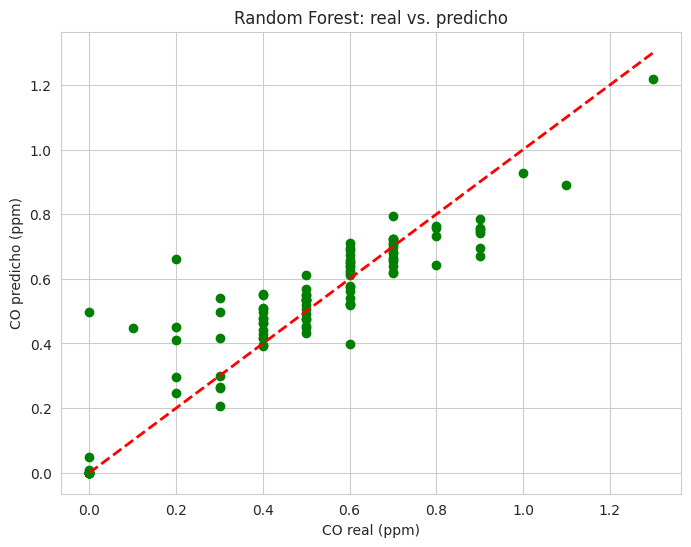

In [40]:
plt.figure(figsize=(8, 6))
plt.scatter(x=y_test, y=test_pred_rf, color="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel("CO real (ppm)")
plt.ylabel("CO predicho (ppm)")
plt.title("Random Forest: real vs. predicho")
plt.show()

<strong> Importancia relativa de las características <strong>

Importancia relativa de las características: [0.369  0.0187 0.0038 0.3448 0.2511 0.0126]


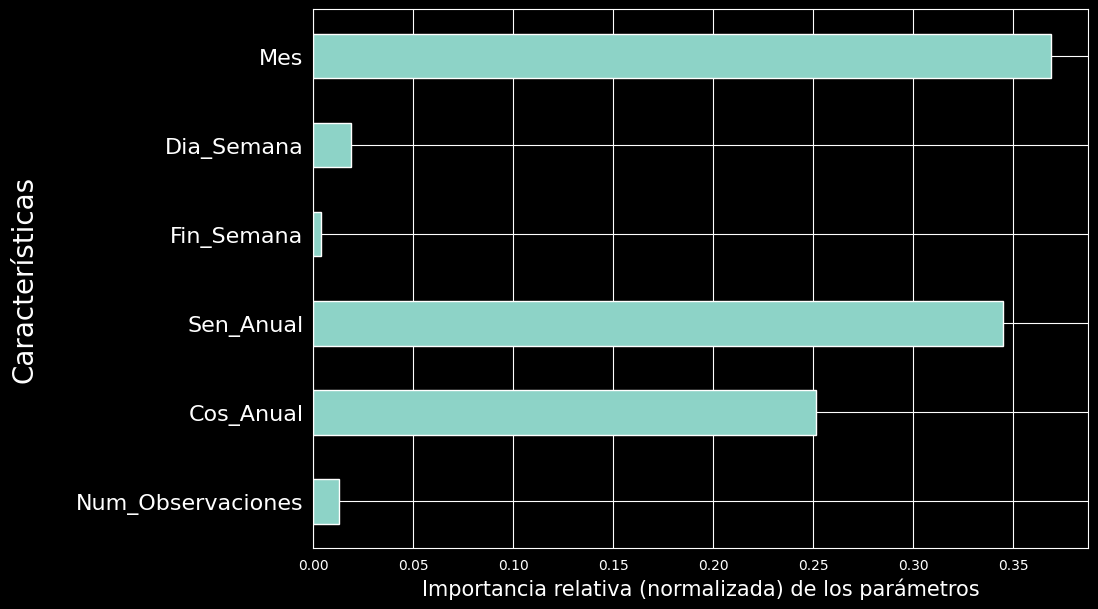

In [41]:
n_features = x_train.shape[1]

print("Importancia relativa de las características:", rf_model.feature_importances_.round(4))

with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 7))
    plt.grid(True)
    plt.yticks(range(n_features, 0, -1), list(x_train.columns), fontsize=16)
    plt.xlabel("Importancia relativa (normalizada) de los parámetros", fontsize=15)
    plt.ylabel("Características\n", fontsize=20)
    plt.barh(range(n_features, 0, -1), width=rf_model.feature_importances_, height=0.5)
    plt.show()

# Comparación de los modelos

In [42]:
resultados = pd.DataFrame({
    "Modelo": ["Regresión Lineal", "Árbol de Decisión", "Random Forest"],
    "MAE": [metrics.mean_absolute_error(y_test, predictions),
            metrics.mean_absolute_error(y_test, test_pred_tree),
            metrics.mean_absolute_error(y_test, test_pred_rf)],
    "RMSE": [np.sqrt(metrics.mean_squared_error(y_test, predictions)),
             np.sqrt(metrics.mean_squared_error(y_test, test_pred_tree)),
             np.sqrt(metrics.mean_squared_error(y_test, test_pred_rf))],
    "R2": [metrics.r2_score(y_test, predictions),
           metrics.r2_score(y_test, test_pred_tree),
           metrics.r2_score(y_test, test_pred_rf)]
}).round(4)

resultados

,Modelo,MAE,RMSE,R2
0,Regresión Lineal,0.1853,0.2369,0.2956
1,Árbol de Decisión,0.1075,0.1588,0.6836
2,Random Forest,0.0727,0.1127,0.8406


Resumen estadístico con statsmodels`statsmodels` entrega un reporte completo del modelo lineal: coeficientes, valores p, R², R² ajustadoy pruebas de significancia, muy útil para interpretar estadísticamente el modelo.

In [43]:
import statsmodels.api as sm

In [44]:
Xs = sm.add_constant(x)
stat_model = sm.OLS(y, Xs)
stat_result = stat_model.fit()
print(stat_result.summary())

                            OLS Regression Results                            
Dep. Variable:                 CO_ppm   R-squared:                       0.331
Model:                            OLS   Adj. R-squared:                  0.320
Method:                 Least Squares   F-statistic:                     29.47
Date:                Thu, 17 Sep 2026   Prob (F-statistic):           1.17e-28
Time:                        21:03:33   Log-Likelihood:                 18.892
No. Observations:                 364   AIC:                            -23.78
Df Residuals:                     357   BIC:                             3.497
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.7380      0.14

## Conclusiones

* **Comportamiento estacional:** La concentración de CO en la estación PARR muestra una clara estacionalidad, alcanzando los valores más altos en meses fríos (diciembre–febrero) y los más bajos en meses cálidos (junio–agosto).
* **Variables clave:** Las variables más relevantes corresponden al **momento del año** (`Mes`, `Sen_Anual` y `Cos_Anual`). El día de la semana y el número de observaciones tienen un impacto despreciable.
* **Limitación del modelo lineal:** La **Regresión Lineal** solo explica parcialmente la variación debido a que la relación entre la fecha y el CO sigue una curva estacional en lugar de una tendencia recta.
* **Modelos no lineales:** Los modelos basados en árboles (**Árbol de Decisión** y **Random Forest**) ofrecen un mejor ajuste al capturar de forma efectiva las relaciones no lineales.
* **Oportunidades de mejora:** Para incrementar la precisión del modelo, se recomienda integrar variables externas clave como **temperatura, velocidad del viento, humedad y tráfico vehicular**.